## BERT for Negation Scope Detection

**Group 4**


`Melina Paxinou    2854344`

Link to fine-tuned model: https://drive.google.com/file/d/1uoVwsPypyEy84mkg1zwYl9Y2_-buZe3Z/view?usp=sharing

## Imports and paths

In [5]:
from collections import Counter
from datasets import load_dataset
from evaluate import load
import pandas as pd
from datasets import Dataset
import numpy as np
from transformers import DataCollatorForTokenClassification
from transformers import set_seed
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer
import transformers
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pickle

In [6]:
# Relative paths to all files, only DATA_DIR needs to be changed
DATA_DIR = '../starsem-st-2012-data/starsem-st-2012-data/cd-sco/corpus/'
train = DATA_DIR + 'training/SEM-2012-SharedTask-CD-SCO-training-09032012.txt'
dev = DATA_DIR+'dev/SEM-2012-SharedTask-CD-SCO-dev-09032012.txt'
test_card = DATA_DIR+'test-gold/SEM-2012-SharedTask-CD-SCO-test-cardboard-GOLD.txt'
test_circle = DATA_DIR+'test-gold/SEM-2012-SharedTask-CD-SCO-test-circle-GOLD.txt'
ann17 = DATA_DIR+'file-17-to-annotate.csv'

## Duplication script for any number of negation cues

In [8]:
def create_dupfile(inputfile, outputfile, rmgold=False):
    """
    Processes a dataset with variable columns and duplicates sentences based on the number of negation cues.

    Parameters:
    inputfile: path to a text file from the dataset
    outputfile: path to a new file with 10 columns and duplicated sentences
    rmgold: Boolean value set to False as default. if set to True, gold labels and syntax are removed from the new file

    This function processes a file with any number of negation cues and creates duplicates in the sentences where
    more than one negation is found. 
    If "cue1" starts with "***", the sentence is removed from our dataset as our task involves searching for 
    a negation scope only when a cue is given.

    If the parameter 'rmgold' is set to True, it removes the gold labels and syntax similarly to the file given in appendix B
    of assignment 1. The default value is False, and if skipped, the function only duplicates the necessary sentences
    without removing any labels.

    The original and duplicated sentences are written to the new file and the function returns nothing.
    """
    
    # defining fixed column names
    fixed_columns = [
        'chapter_name', 'sentence_number', 'token_number', 'word', 'lemma',
        'part-of-speech', 'syntax'
    ]

    # updating the maximum possible number of columns by checking the length of each row in the dataset
    rows = []
    max_columns = 0

    with open(inputfile, 'r', encoding='utf-8') as file:
        for line in file:
            if line.strip():  # skipping empty lines
                row = line.strip().split('\t')
                rows.append(row)
                max_columns = max(max_columns, len(row))

    # generating dynamic column names
    num_fixed_columns = len(fixed_columns)
    num_dynamic_columns = max_columns - num_fixed_columns
    # if the columns are not 0 and if they can be divided by 3
    if num_dynamic_columns % 3 != 0:
        raise ValueError("Negation columns are not in multiples of 3.")
    num_cues = num_dynamic_columns // 3
    dynamic_columns = [
        f'{name}{i + 1}' for i in range(num_cues) for name in ['cue', 'scope', 'event']
    ]

    # combining fixed and dynamic columns
    column_names = fixed_columns + dynamic_columns

    # creating a df with the parsed rows and dynamic columns
    df = pd.DataFrame(rows, columns=column_names).fillna('')

    # grouping sentences by chapter name and sentence number and disabling automatic sorting
    sentences = df.groupby(['chapter_name', 'sentence_number'], sort=False)

    # defining output columns
    output_columns = [
        'chapter_name', 'sentence_number', 'token_number', 'word', 'lemma',
        'part-of-speech', 'syntax', 'cue', 'scope', 'event'
    ]

    # writing sentences to the output file
    with open(outputfile, 'w', encoding='utf-8') as newfile:
        for (chapter_name, sentence_number), group in sentences:

            if (group['cue1'] == '***').any():
                continue

            # removing gold labels and syntax if rmgold is True
            if rmgold:
                group['syntax'] = '_'
                for col in dynamic_columns:
                    if col.startswith('scope') or col.startswith('event'):
                        group[col] = '_'

            duplications = []

            # processing each cue dynamically
            for i in range(num_cues):
                cue_col = f'cue{i + 1}'
                scope_col = f'scope{i + 1}'
                event_col = f'event{i + 1}'

                if cue_col in group and not group[cue_col].empty:
                    # checking if the cue column contains alphabetic content or negation or '***'
                    if group[cue_col].fillna('').astype(str).apply(str.isalpha).any() or (group[cue_col] == "n't").any() or (group[cue_col] == "***").any():
                        duplication = group.copy()
                        duplication['sentence_number'] = f"{
                            sentence_number}_{i + 1}"
                        duplication['cue'] = duplication[cue_col]
                        duplication['scope'] = duplication[scope_col]
                        duplication['event'] = duplication[event_col]
                        duplication = duplication[output_columns]
                        duplications.append(duplication)

            # writing each duplication
            for dup in duplications:
                dup.to_csv(newfile, sep='\t', header=False, index=False)

In [9]:
# change to True if you want gold labels and syntax removed
create_dupfile(dev, 'duplicated_dev.txt', rmgold=False)
create_dupfile(test_card, 'duplicated_test_card.txt', rmgold=False)
create_dupfile(test_circle, 'duplicated_test_circle.txt', rmgold=False)
create_dupfile(ann17, 'duplicated_anno.csv', rmgold=False)
create_dupfile(train, 'duplicated_train.txt', rmgold=False)

In [10]:
dup_train = 'duplicated_train.txt'
dup_dev = 'duplicated_dev.txt'
dup_test_card = 'duplicated_test_card.txt'
dup_test_circle = 'duplicated_test_circle.txt'

In [11]:
dup_test = 'cleaned_dup_combined_test.txt'

# combining the two test files
with open(dup_test, 'w') as new_file:
    with open(dup_test_circle, 'r') as file1:
        for line in file1:
            if line.strip():
                new_file.write(line)

    with open(dup_test_card, 'r') as file2:
        for line in file2:
            if line.strip():
                new_file.write(line)

## Statistics

In [13]:
def read_conll(file):
    """
    Reads a CoNLL-formatted file and extracts linguistic annotations into a structured list of dictionaries.

    Each line in the file represents a token with multiple attributes, separated by tab spaces. The function 
    parses these attributes dynamically to handle any number of negation cues, scopes, and events, organizing 
    them into dictionaries, one per token.

    Parameters:
        file (str): Path to the CoNLL-formatted file to be read.

    Returns:
        list[dict]: A list of dictionaries where each dictionary corresponds to a line in the file and 
        contains the following keys:
            - 'chapter' (str): Chapter identifier for the token.
            - 'sent_num' (str): Sentence number within the chapter.
            - 'word_num' (str): Token number within the sentence.
            - 'word' (str): The actual word/token.
            - 'lemma' (str): Lemmatized form of the token.
            - 'pos' (str): Part-of-speech tag of the token.
            - 'syntax' (str): Syntactic role of the token.
            - 'negX' (str): Negation cue for each dynamic index X.
            - 'scopeX' (str or None): Scope for the corresponding negation cue X, if available.
            - 'eventX' (str or None): Event for the corresponding negation cue X, if available.

    Notes:
        - The function dynamically handles any number of negation cue, scope, and event columns.
        - If a line has fewer than the expected columns, missing values are set to 'None'.

    """
    data = []
    with open(file, 'r', encoding='utf8') as infile:
        for line in infile:
            components = line.rstrip('\n').split()
            if len(components) > 0:
                # Core attributes
                chapter, sent_num, word_num, word, lemma, pos, syntax = components[:7]
                dynamic_fields = components[7:]

                # dynamically extract neg, scope, and event columns
                # ensure 'none' is treated as a valid value (as one of the negation cue)
                if dynamic_fields:
                    neg_cues = len(dynamic_fields) // 3
                    cols = {
                        'chapter': chapter,
                        'sent_num': sent_num,
                        'word_num': word_num,
                        'word': word,
                        'lemma': lemma,
                        'pos': pos,
                        'syntax': syntax
                    }
                    for i in range(neg_cues):
                        neg_idx = i * 3
                        neg_value = dynamic_fields[neg_idx].strip().lower()
                        cols[f'neg{i + 1}'] = neg_value if neg_value != 'None' else None  # exclude uppercase 'None'
                        cols[f'scope{i + 1}'] = dynamic_fields[neg_idx + 1]
                        cols[f'event{i + 1}'] = dynamic_fields[neg_idx + 2]
                    data.append(cols)

    return data

In [14]:
def find_sents(df):
    """
    Calculates the total number of unique sentences across all chapters in a given DataFrame.

    The function assumes the DataFrame contains columns named 'chapter' and 'sent_num', where:
    - 'chapter' identifies the chapter each row belongs to.
    - 'sent_num' identifies the sentence number within the chapter.

    Parameters:
        df (pandas.DataFrame): A Pandas DataFrame of the data

    Returns:
        int: The total number of unique sentences across all chapters in the DataFrame.

    Notes:
        - The function uses `set` to determine unique sentence numbers within each chapter.
        - The column names in the DataFrame must match 'chapter' and 'sent_num' exactly.

    """
    chapters = list(set(list(df['chapter'])))

    count = 0
    for chapter in chapters:
        # checks the unique sent numbers for every chapter and adds it to the count of all sentences
        count += len(set(df[df['chapter'] == chapter]['sent_num']))
    return count

In [15]:
def find_stats(df):
    """
    Computes various statistics related to negation in a given DataFrame.

    This function analyzes negation cues and their scopes in the dataset, dynamically processing 
    any number of negation-related columns. It produces a dictionary with information about the 
    number of sentences, words, negation cues, and their distributions.

    Parameters:
        df (pandas.DataFrame): A DataFrame containing at least the following columns:
            - 'chapter' (str): Chapter identifier.
            - 'sent_num' (str): Sentence number within the chapter.
            - 'word' (str): Token in the sentence.
            - 'negX' (str): Negation cues for each dynamic index X, where '_', '***', and None indicate absence.
            - 'scopeX' (str): Scope annotations for each dynamic index X, where '_', '***', and None indicate absence.

    Returns:
        dict: A dictionary containing the following statistics:
            - 'num_sent' (int): Total number of sentences in the DataFrame.
            - 'num_words' (int): Total number of words in the DataFrame.
            - 'num_neg_cue_ins' (int): Number of negation cue instances.
            - 'num_uni_neg_cue' (int): Number of unique negation cue forms.
            - 'num_neg_cue_tokens' (int): Total number of tokens used in all negation cues.
            - 'num_token_in_scope' (int): Number of tokens inside a negation scope.
            - 'num_token_out_scope' (int): Number of tokens outside a negation scope.
            - 'neg_distribution' (Counter): Distribution of negation cues (frequency of each negation cue).

    Notes:
        - The function dynamically identifies negation-related columns (negX, scopeX, etc.).
        - Negation cue keys are tracked as 'chapter_sent_num_negX' to track their occurrences.

    """
    neg_columns = [col for col in df.columns if col.startswith("neg")]
    scope_columns = [col for col in df.columns if col.startswith("scope")]

    # ensure all neg_columns are strings
    for neg_col in neg_columns:
        # replace 'nan', '_', '***') with empty strings ''
        df[neg_col] = df[neg_col].astype(str).replace({'nan': '', '_': '', '***': ''})

    # negation cues statistics
    final_dict = {}
    for neg_col in neg_columns:
        for index, row in df.iterrows():
            neg_value = row[neg_col].strip()
            if neg_value and neg_value not in ('_', '', '***', 'None'):  # keep valid 'none' to avoid missed count in Test Circle
                neg_value = neg_value.lower()
                key = f"{row['chapter']}_{row['sent_num']}_{neg_col}"
                if key in final_dict:
                    final_dict[key] += f" {neg_value}"
                else:
                    final_dict[key] = neg_value


    # total number of negation cue tokens
    count = sum(len(cue.split()) for cue in final_dict.values())

    # Scope statistics
    in_count = 0
    out_count = 0
    for index, row in df.iterrows():
        inside_scope = False #check if the token is inside any scope
        for scope_col in scope_columns:
            #pd.notna() returns True if the value is valid (not NaN or None)
            scope_value = str(row[scope_col]).strip() if pd.notna(row[scope_col]) else ''
            if scope_value not in ('_', '', '***', 'none'):
                inside_scope = True
                break # if the scope value is valid, stop checking further
        if inside_scope:
            in_count += 1
        else:
            out_count += 1

    # Compile statistics
    data = {
        'num_sent': find_sents(df),
        'num_words': len(df),
        'num_neg_cue_ins': len(final_dict),
        'num_uni_neg_cue': len(set(final_dict.values())),
        'num_neg_cue_tokens': count,
        'num_token_in_scope': in_count,
        'num_token_out_scope': out_count,
        'neg_distribution': Counter(final_dict.values()),
    }

    # Print results
    print(f"""
    {"Total number of sentences in the Text:":<52} {data['num_sent']}
    {"Total number of words in the Text:":<52} {data['num_words']}
    {"Number of negation cue instances:":<52} {data['num_neg_cue_ins']}
    {"Number of unique negation cue forms:":<52} {data['num_uni_neg_cue']}
    {"Total number of tokens used in all negation cues:":<52} {data['num_neg_cue_tokens']}
    {"Number of tokens inside a negation scope:":<52} {data['num_token_in_scope']}
    {"Number of tokens outside a negation scope:":<52} {data['num_token_out_scope']}
    Distribution of negation cues (frequency of each negation cue):
    """)

    max_cue_length = max(len(cue) for cue in data['neg_distribution'].keys()) if data['neg_distribution'] else 0
    for cue, count in data['neg_distribution'].items():
        print(f"{cue:<{max_cue_length}} : {count}")

    return data


In [16]:
# Initialising dataframes for all files, the csv file is given column names to reference data

# Before Duplication
dev_df = pd.DataFrame.from_dict(read_conll(dev))
test_card_df = pd.DataFrame.from_dict(read_conll(test_card))
test_circle_df = pd.DataFrame.from_dict(read_conll(test_circle))
train_df = pd.DataFrame.from_dict(read_conll(train))

ann17_df = pd.read_csv(ann17, delimiter='\t', header=None, names=[
                       'chapter', 'sent_num', 'word_num', 'word', 'lemma', 'pos', 'syntax',
                       'neg1', 'scope1', 'event1', 'neg2', 'scope2', 'event2', 'neg3', 'scope3', 'event3'], keep_default_na=False, na_values=[""])
ann17_df = ann17_df.map(lambda x: None if pd.isna(x) else x)

# keep_default_na = False -- we do this as some words like "None" were read as not available
# na_values=[""] -- this makes sure we still read "" as not available data and all "" become NaN
# ann17_df = ann17_df.map(lambda x: None if pd.isna(x) else x) -- this converts all NaN into None type data which we have conditions set up for

In [17]:
for i in [{'val': dev_df, 'name': 'Dev'}, {'val': test_card_df, 'name': 'Test Card'}, 
          {'val': test_circle_df, 'name': 'Test Circle'}, {'val': ann17_df, 'name': '17 Sentences to annotate'}]:
    print(i['name']+':')
    find_stats(i['val'])
    print('\n\n')

Dev:

    Total number of sentences in the Text:               787
    Total number of words in the Text:                   13567
    Number of negation cue instances:                    173
    Number of unique negation cue forms:                 20
    Total number of tokens used in all negation cues:    179
    Number of tokens inside a negation scope:            1290
    Number of tokens outside a negation scope:           12277
    Distribution of negation cues (frequency of each negation cue):
    
no          : 32
not         : 42
un          : 16
never       : 11
im          : 6
n't         : 20
neither nor : 2
nothing     : 16
without     : 7
no nor      : 1
by no means : 1
neither     : 1
ir          : 1
in          : 5
nor         : 4
save        : 1
less        : 3
dis         : 2
nobody      : 1
no more     : 1



Test Card:

    Total number of sentences in the Text:               496
    Total number of words in the Text:                   10184
    Number of negation cu

In [18]:
# After Duplication -- please run only after files have been generated in the same directory as notebook
dup_dev_df = pd.DataFrame.from_dict(read_conll('duplicated_dev.txt'))
dup_test_card_df = pd.DataFrame.from_dict(
    read_conll('duplicated_test_card.txt'))
dup_test_circle_df = pd.DataFrame.from_dict(
    read_conll('duplicated_test_circle.txt'))
dup_train_df = pd.DataFrame.from_dict(read_conll('duplicated_train.txt'))
dup_all_test_df = pd.DataFrame.from_dict(read_conll(dup_test))
dup_ann17_df = pd.read_csv('duplicated_anno.csv', delimiter='\t', header=None, names=[
    'chapter', 'sent_num', 'word_num', 'word', 'lemma', 'pos', 'syntax',
    'neg1', 'scope1', 'event1', 'neg2', 'scope2', 'event2', 'neg3', 'scope3', 'event3'], keep_default_na=False, na_values=[""])
dup_ann17_df = dup_ann17_df.map(lambda x: None if pd.isna(x) else x)

In [19]:
for i in [{'val': dup_dev_df, 'name': 'Dev'}, {'val': dup_test_card_df, 'name': 'Test Card'}, 
          {'val': dup_test_circle_df, 'name': 'Test Circle'},
          {'val': dup_ann17_df, 'name': '17 Sentences to annotate'}, {'val': dup_all_test_df, 'name': 'Combined train data'}]:
    print(i['name']+':')
    find_stats(i['val'])
    print('\n\n')

Dev:

    Total number of sentences in the Text:               173
    Total number of words in the Text:                   3592
    Number of negation cue instances:                    173
    Number of unique negation cue forms:                 20
    Total number of tokens used in all negation cues:    179
    Number of tokens inside a negation scope:            1368
    Number of tokens outside a negation scope:           2224
    Distribution of negation cues (frequency of each negation cue):
    
no          : 32
not         : 42
un          : 16
never       : 11
im          : 6
without     : 7
n't         : 20
neither nor : 2
nothing     : 16
nor         : 4
no nor      : 1
by no means : 1
neither     : 1
ir          : 1
in          : 5
less        : 3
save        : 1
dis         : 2
nobody      : 1
no more     : 1



Test Card:

    Total number of sentences in the Text:               133
    Total number of words in the Text:                   3130
    Number of negation cue i

## Loading the dataset

In [21]:
# defining task, model, and batch size
task = "scope_detection"
model_checkpoint = "distilbert-base-uncased"
batch_size = 16

To ensure that the datasets are in a form which can be read by the model, a number of steps need to be taken. First, we created dataframes for each set (train, dev, combined test).



In [23]:
# creating dataframes for train, dev, and test files

# defining column names for easier access to elements
column_names = [
        "chapter_name",
        "sentence_number",
        "token_number",
        "word",
        "lemma",
        "part-of-speech",
        "syntax",
        "cue",
        "scope",
        "event",
    ]

dev_df = pd.read_csv(
        dup_dev,
        sep="\t",
        names=column_names,
        encoding="utf-8",
        na_filter=False, # handles empty strings and makes sure they remain as empty and not as NaN values
    )

train_df = pd.read_csv(
        dup_train,
        sep="\t",
        names=column_names,
        encoding="utf-8",
        na_filter=False,
    )

test_df = pd.read_csv(
        dup_test,
        sep="\t",
        names=column_names,
        encoding="utf-8",
        na_filter=False,
    )

In [24]:
# example of dataframe
train_df

,chapter_name,sentence_number,token_number,word,lemma,part-of-speech,syntax,cue,scope,event
0,baskervilles01,1_1,0,Mr.,Mr.,NNP,(S(NP(NP*,_,_,_
1,baskervilles01,1_1,1,Sherlock,Sherlock,NNP,*,_,_,_
2,baskervilles01,1_1,2,Holmes,Holmes,NNP,*),_,_,_
3,baskervilles01,1_1,3,",",",",",",*,_,_,_
4,baskervilles01,1_1,4,who,who,WP,(SBAR(WHNP*),_,_,_
...,...,...,...,...,...,...,...,...,...,...
22115,baskervilles14,270_1,58,slopes,slope,NNS,*),_,_,_
22116,baskervilles14,270_1,59,of,of,IN,(PP*,_,_,_
22117,baskervilles14,270_1,60,the,the,DT,(NP*,_,_,_
22118,baskervilles14,270_1,61,moor,moor,NN,*)))))))))))))))))))))))))))),_,_,_


## Preprocessing

The next step is to convert each set into a list of dictionaries which contain the following keys: id, tokens, labels, cues, og_cues.

In [27]:
def convert_df(df):
    """
    Converts a DataFrame containing negation annotations into a list of dictionaries suitable for BERT.

    Parameters:
    df : pandas.DataFrame
        Input DataFrame with the following required columns:
        - chapter_name: Name of the chapter
        - sentence_number: Sequential number identifying each sentence
        - word: Individual tokens/words in the sentence
        - scope: Scope annotations ('_' for out-scope, other values for in-scope)
        - cue: Cue annotations ('_' for no cue, other values for cue)

    Returns:
    list of dict
        List where each dictionary represents a sentence with the following keys:
        - id: String identifier 
        - tokens: List of words in the sentence
        - labels: Binary list indicating scope (0 for out-scope, 1 for in-scope)
        - cues: Binary list indicating cues (0 for no cue, 1 for cue)
        - og_cues: Original cue annotations before binarization
        
    Notes:
    - The function creates a unique sentence identifier by combining chapter_name 
      and sentence_number
    - Scope and cue values are binarized: '_' becomes 0, any other value becomes 1
    - Original cue values are preserved in 'og_cues' for reference
    """

        
    # combining chapter_name and sentence_number into a unique sentence ID
    df['sentence_id'] = df['chapter_name'].astype(str) + '_' + df['sentence_number'].astype(str)
    
    
    # grouping by sentence ID and constructing the dictionaries
    result = [
        {
            'id': str(i),
            'tokens': group['word'].tolist(),
            'labels': [0 if item == '_' else 1 for item in group['scope']] ,
            'cues': [0 if val == '_' else 1 for val in group['cue']],
            'og_cues': group['cue'].tolist()
        }
        for i, (_, group) in enumerate(df.groupby('sentence_id',sort=False))
    ]
    
    # returning the result
    return result

In [28]:
# applying the convert_df function to all the dataframes 
dev_data = convert_df(dev_df)
train_data = convert_df(train_df)
test_data = convert_df(test_df)

In [29]:
# example of dictionary
print(test_data[0])

{'id': '0', 'tokens': ['``', 'Well', ',', 'Mrs.', 'Warren', ',', 'I', 'can', 'not', 'see', 'that', 'you', 'have', 'any', 'particular', 'cause', 'for', 'uneasiness', ',', 'nor', 'do', 'I', 'understand', 'why', 'I', ',', 'whose', 'time', 'is', 'of', 'some', 'value', ',', 'should', 'interfere', 'in', 'the', 'matter', '.'], 'labels': [0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'cues': [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'og_cues': ['_', '_', '_', '_', '_', '_', '_', '_', 'not', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_']}


The following special tokens are added to the dictionaries: [MULTI], [NEG], [PRE], [POST]. We are using the augmentation technique from "NegBERT: A Transfer Learning Approach for Negation Detection and Scope Resolution" by adding the appropriate special token before each negation cue. [MULTI] is added before multi-word negations, [NEG] is added before simple negations, [PRE] is added before prefix negations, and [POST] is added before suffix negations. This is why we need `og_cues` and not simply `cues`. This function also updates the labels by adding the value '-100' in the place of the special tokens that we added. It also preserves `cues` and `og_cues` by giving them the appropriate padding.

In [31]:
def augment_data(data):
    """
    Takes as input a list of dictionaries containing tokens, cue information, and labels. It adds special tokens 
    to indicate different types of negation patterns and updates the labels for the inserted tokens. The original 
    sequence of tokens is preserved, and the function handles multiple or single-word cues, as well as prefix 
    and suffix negation cues.

    Parameters:
    data (list of dict): A list of dictionaries where each dictionary contains:
    - 'tokens': list of strings (tokens of a sentence).
    - 'cues': list showing which tokens are part of a negation cue (0 for no cue, 1 for cue).
    - 'og_cues': original cue annotations for each token.
    - 'labels': labels for each token.

    Returns:
    A list of dictionaries with:
    - Special tokens like [MULTI], [NEG], [PRE], or [POST] added to the token list.
    - Labels updated to -100 for the inserted special tokens.
    - Cues and original cue lists padded to match the updated token list.
    """
        
    final =[]
    for sentence in data:
        
        # extracting necessary lists
        tokens = sentence['tokens']
        cues = sentence['cues']
        og_cues = sentence['og_cues']
        labels = sentence['labels']
    
        # counting the number of 1s in the cues -- 1 indicates the cue
        cue_count = cues.count(1)
    
        # processing tokens based on the cues
        processed_tokens = []
        processed_labels = []
        processed_cues = []
        processed_og_cues = []
        for idx, (token, cue) in enumerate(zip(tokens, cues)):
            if cue == 1:
                processed_labels.append(-100)
                processed_cues.append(cues[idx])
                processed_og_cues.append(og_cues[idx])
                # Multiple cues: mark as [MULTI]
                if cue_count > 1:
                    processed_tokens.append("[MULTI]")
                # Single cue: mark based on position
                elif og_cues[idx] == token:
                    processed_tokens.append("[NEG]")  
                else:
                    if token.startswith(og_cues[idx]):
                        processed_tokens.append("[PRE]")
                    else:
                        processed_tokens.append("[POST]")
            processed_tokens.append(token)
            processed_labels.append(labels[idx])
            processed_cues.append(cues[idx])
            processed_og_cues.append(og_cues[idx])
    
        final.append({
            'tokens':processed_tokens,
            'labels': processed_labels,
            'cues': processed_cues,
            'og_cues': processed_og_cues
        })
    return final

In [32]:
train_aug = augment_data(train_data)
dev_aug =augment_data(dev_data)
test_aug =augment_data(test_data)

In [33]:
#example of augmented data
print(test_aug[0])

{'tokens': ['``', 'Well', ',', 'Mrs.', 'Warren', ',', 'I', 'can', '[NEG]', 'not', 'see', 'that', 'you', 'have', 'any', 'particular', 'cause', 'for', 'uneasiness', ',', 'nor', 'do', 'I', 'understand', 'why', 'I', ',', 'whose', 'time', 'is', 'of', 'some', 'value', ',', 'should', 'interfere', 'in', 'the', 'matter', '.'], 'labels': [0, 0, 0, 0, 0, 0, 1, 1, -100, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'cues': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'og_cues': ['_', '_', '_', '_', '_', '_', '_', '_', 'not', 'not', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_']}


Before we can feed those texts to our model, we need to preprocess them. This is done by a 🤗 Transformers `Tokenizer` which will (as the name indicates) tokenize the inputs (including converting the tokens to their corresponding IDs in the pretrained vocabulary) and put it in a format the model expects, as well as generate the other inputs that model requires.

To do all of this, we instantiate our tokenizer with the `AutoTokenizer.from_pretrained` method, which will ensure:

- we get a tokenizer that corresponds to the model architecture we want to use,
- we download the vocabulary used when pretraining this specific checkpoint.

That vocabulary will be cached, so it's not downloaded again the next time we run the cell.

In [35]:
# loading tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [36]:
# four special tokens have been added to the tokenizer vocabulary, which represent the negation cue types
tokenizer.add_tokens(['[PRE]', '[POST]', '[MULTI]', '[NEG]'])

4

We pass our input to the tokenizer, however, since the datasets are already split in words, we use the argument `is_split_into_words=True`. Although our text is already tokenized, BERT works with subtokens, which means that our words could be split in more words by this tokenizer. After the function `tokenized_input` is ran, the dictionaries will also contain input_ids, attention_mask, word_ids, and tokenized_tokens.

In [38]:
def tokenized_input(data):
    """
    Takes as input a list of sentences (each represented as a dictionary) and tokenizes them using a transformer 
    tokenizer. It aligns the original labels with the tokenized tokens, ensures that special tokens are ignored 
    during label alignment, and adds the necessary fields for model input.
        
    Modifies each sentence dictionary in place by adding:
    - labels (list of integers): aligned labels where -100 represents tokens that are special tokens 
    - input_ids (list of integers): token ids for the model
    - attention_mask (list of integers): attention mask for the model
    - word_ids (list of integers): mapping from token positions to word positions
    - tokenized_tokens (list of integers): subtokens after tokenization

    Parameters:
    data (list of dict): A list of dictionaries where each dictionary contains:
    - 'tokens': List of words in the sentence.
    - 'labels': Labels for each word in the sentence.

    Returns:
    The list of dictionaries with the added components.
    """
    tokenized_data=[]
    for sent in data:
        single_sent=sent.copy()
        tokenized_input = tokenizer(sent["tokens"], is_split_into_words=True)
        tokens = tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
        word_ids = tokenized_input.word_ids()
        aligned_labels = [-100 if i is None else sent["labels"][i] for i in word_ids]
        
        single_sent["labels"] = aligned_labels
        single_sent["input_ids"] = tokenized_input["input_ids"]
        single_sent["attention_mask"] = tokenized_input["attention_mask"]
        single_sent['word_ids'] = word_ids
        single_sent['tokenized_tokens'] = tokens
        tokenized_data.append(single_sent)
    return tokenized_data


In [39]:
train_tok = tokenized_input(train_aug)
dev_tok = tokenized_input(dev_aug)
test_tok = tokenized_input(test_aug)

In [40]:
# example of dictionary with subtokens (see the key 'tokenized_tokens')
print(test_tok[0])

{'tokens': ['``', 'Well', ',', 'Mrs.', 'Warren', ',', 'I', 'can', '[NEG]', 'not', 'see', 'that', 'you', 'have', 'any', 'particular', 'cause', 'for', 'uneasiness', ',', 'nor', 'do', 'I', 'understand', 'why', 'I', ',', 'whose', 'time', 'is', 'of', 'some', 'value', ',', 'should', 'interfere', 'in', 'the', 'matter', '.'], 'labels': [-100, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, -100, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -100], 'cues': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'og_cues': ['_', '_', '_', '_', '_', '_', '_', '_', 'not', 'not', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_'], 'input_ids': [101, 1036, 1036, 2092, 1010, 3680, 1012, 6031, 1010, 1045, 2064, 30525, 2025, 2156, 2008, 2017, 2031, 2151, 3327, 3426, 2005, 16655, 21369, 2791, 1010, 4496, 20

Our dictionary contains unnecessary information at this point, so we use the function `preprocess_example` to create dictionaries with the keys that BERT can read: input_ids, attention_mask, labels. 

In [42]:
def preprocess_example(example):
    """
    Takes as input a dictionary containing information of a training sentence and extracts the 
    necessary keys required for training. It ensures that only the relevant keys 
    (input_ids, attention_mask, and labels) are returned.

    Parameters:
    example (dictionary): A dictionary that contains the following keys:
    - 'input_ids': list of token IDs
    - 'attention_mask': mask for model
    - 'labels': labels for each token in the sequence

    Returns:
    A dictionary with only the following keys:
    - 'input_ids'
    - 'attention_mask'
    - 'labels'
    """
    return {
        "input_ids": example["input_ids"],
        "attention_mask": example["attention_mask"],
        "labels": example["labels"]
    }

In [43]:
# preprocessing the dataset
processed_train = [preprocess_example(example) for example in train_tok]
processed_dev = [preprocess_example(example) for example in dev_tok]
processed_test = [preprocess_example(example) for example in test_tok]

In [44]:
# example of dictionary that contains only the keys that are relevant to BERT
# at this point we have the input ids, attention mask, and labels, all with the necessary padding
print(processed_test[0])

{'input_ids': [101, 1036, 1036, 2092, 1010, 3680, 1012, 6031, 1010, 1045, 2064, 30525, 2025, 2156, 2008, 2017, 2031, 2151, 3327, 3426, 2005, 16655, 21369, 2791, 1010, 4496, 2079, 1045, 3305, 2339, 1045, 1010, 3005, 2051, 2003, 1997, 2070, 3643, 1010, 2323, 15115, 1999, 1996, 3043, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [-100, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, -100, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -100]}


## Fine-tuning the model

In [46]:
# loading pre-trained transformer model (BERT) from the model_checkpoint
model = AutoModelForTokenClassification.from_pretrained(model_checkpoint, num_labels=2) 
# adjusting the model's embedding layer to match the size of the tokenizer's vocabulary to account for the tokens that we added
model.resize_token_embeddings(len(tokenizer))

Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(30526, 768, padding_idx=0)

The warning is telling us we are throwing away some weights (the `vocab_transform` and `vocab_layer_norm` layers) and randomly initializing some other (the `pre_classifier` and `classifier` layers). This is absolutely normal in this case, because we are removing the head used to pretrain the model on a masked language modeling objective and replacing it with a new head for which we don't have pretrained weights, so the library warns us we should fine-tune this model before using it for inference, which is exactly what we are going to do.

To instantiate a `Trainer`, we will need to define three more things. The most important is the [`TrainingArguments`](https://huggingface.co/transformers/main_classes/trainer.html#transformers.TrainingArguments), which is a class that contains all the attributes to customize the training. It requires one folder name, which will be used to save the checkpoints of the model, and all other arguments are optional:

In this assignment, we experiment with different random seeds and see what the outcome is on the performance of the model. The random seed influences the following steps when training (amongst others):


*  **Weight Initialization:** When we start training, the values for the weights are randomly assigned. This is controlled by the random seed. This impacts the training trajectory in the weight space, e.g. determines which local minimum the model can end up in.
*  **Data Order**: The order in which the model sees the data is also controlled by the random seed. This also influences the training trajectory, determining which data points are e.g. influential in the beginning.


Setting the random seed with a specific numerical value (e.g. 0) makes sure that we can reproduce the results again, introducing some kind of deterministic behavior.

In [49]:
# Set random seed!
SEED = 127
set_seed(SEED)

model_name = model_checkpoint
args = TrainingArguments(
    f"{model_name}-finetuned-{task}",    # output directory name
    eval_strategy = "epoch",    # evaluation will be performed at the end of each epoch
    learning_rate=2e-5,    # 0.00002 (2e-5) is a common value for transformer fine-tuning
    per_device_train_batch_size=batch_size,    # number of training examples processed in parallel per device during training
    per_device_eval_batch_size=batch_size,    # number of evaluation examples processed in parallel per device during evaluation
    num_train_epochs=3,    # the total number of complete passes (epochs) through the dataset during training
    weight_decay=0.01,    # a weight decay of 0.01 is applied for regularization to reduce the risk of overfitting
    seed=SEED,    # seed set by each group member to ensure reproducibility 
    report_to=None,    # disables reporting to external tracking services
    logging_dir='./logs',    # directory where training logs will be saved 
    # Training loss measures the difference between the model's predictions and the true labels during training       
    logging_steps=10,    # logs training metrics every 10 steps
)

In [50]:
# Finds the longest sequence length in processed_train, processed_dev, and processed_test to determine the max_len
max_len = max(max([len(sent['input_ids']) for sent in processed_train]) , max([len(sent['input_ids']) for sent in processed_dev]) ,max([len(sent['input_ids']) for sent in processed_test]))

# Uses a data collator to batch the processed examples while padding all sequences to the maximum length (max_len).
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,    # using our tokenizer
    padding='max_length',    # padding all sequences to the same length 
    max_length=max_len,    # defining the max length that we found above
)

In [51]:
# loading the seqeval metric, a library commonly used for evaluating sequence labeling tasks
metric = load("seqeval")

In [52]:
def compute_metrics(p):
    """
    Takes as input the predictions and gold labels and calculates evaluation metrics 
    (precision, recall, F1 score, and accuracy) for classification. Special tokens 
    (with label -100) are ignored.

    Parameters:
    p (tuple): A tuple containing:
    - 'predictions': model predictions for each token
    - 'labels': gold labels for each token, with special tokens labeled as -100

    Returns:
    A dictionary with: precision, recall, f-score, and accuracy
    """
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)    # normalizes output in 0 and 1

    # removing ignored index (special tokens)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

Although the dictionary we made contained the correct keys and values for BERT, it still needed to be in a compatible format for it to read. Therefore, we used the `datasets` library to convert it.

In [54]:
def make_dataset(processed_doc):
    """
    Takes as input a processed document (list of dictionaries) and creates a dataset
    suitable for BERT training. It extracts the input IDs, attention masks, and labels from 
    each example in the processed list of dictionaries and organizes them into a dataset.

    Parameters:
    processed_doc (list of dictionaries): A list of dictionaries, where each dictionary contains:
    - 'input_ids': list of token IDs
    - 'attention_mask': attention mask for the model
    - 'labels': list of labels corresponding to each token 

    Returns:
    A dataset made with the datasets library containing:
    - 'input_ids'
    - 'attention_mask'
    - 'labels'
    """
    
    final_dataset = Dataset.from_dict({
        'input_ids': [example['input_ids'] for example in processed_doc],
        'attention_mask': [example['attention_mask'] for example in processed_doc],
        'labels': [example['labels'] for example in processed_doc]
    })
    return final_dataset

label_list = ['OUT' , 'IN']
# converting processed_data (list of dicts) into a Dataset
train_dataset = make_dataset(processed_train)
dev_dataset = make_dataset(processed_dev)
test_dataset = make_dataset(processed_test)

In [55]:
# example of a dataset format compatible with BERT
print(test_dataset[:1])

{'input_ids': [[101, 1036, 1036, 2092, 1010, 3680, 1012, 6031, 1010, 1045, 2064, 30525, 2025, 2156, 2008, 2017, 2031, 2151, 3327, 3426, 2005, 16655, 21369, 2791, 1010, 4496, 2079, 1045, 3305, 2339, 1045, 1010, 3005, 2051, 2003, 1997, 2070, 3643, 1010, 2323, 15115, 1999, 1996, 3043, 1012, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'labels': [[-100, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, -100, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -100]]}


In [56]:
trainer = Trainer(
    model,
    args,
    train_dataset=train_dataset,    # training on train
    eval_dataset=dev_dataset,    # evaluating on dev
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

C:\Users\melou\AppData\Local\Temp\ipykernel_2180\2188118681.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [57]:
# training
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.360800,0.390576,0.465823,0.619529,0.531792,0.835900
2,0.159900,0.315758,0.619318,0.734007,0.671803,0.886897
3,0.118100,0.311412,0.633238,0.744108,0.684211,0.891442


C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: IN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: OUT seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: IN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: OUT seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


TrainOutput(global_step=186, training_loss=0.26619777243624454, metrics={'train_runtime': 199.8829, 'train_samples_per_second': 14.769, 'train_steps_per_second': 0.931, 'total_flos': 70809897307968.0, 'train_loss': 0.26619777243624454, 'epoch': 3.0})

In [58]:
# predicting
predictions, labels, _ = trainer.predict(test_dataset)
predictions = np.argmax(predictions, axis=2)

## Evaluation

In [60]:
trainer.evaluate()

C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: IN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: OUT seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


{'eval_loss': 0.3114117383956909,
 'eval_precision': 0.6332378223495702,
 'eval_recall': 0.7441077441077442,
 'eval_f1': 0.6842105263157894,
 'eval_accuracy': 0.8914415551628376,
 'eval_runtime': 3.3761,
 'eval_samples_per_second': 51.242,
 'eval_steps_per_second': 3.258,
 'epoch': 3.0}

We added `predictions` and `gold` to our dictionary to be able to create the classification report and confusion matrix. We added as many predictions and gold labels to the dictionary as the length of the word ids, as the remaining predictions and labels would be padding.

In [62]:
for idx, i in enumerate(test_tok):
    length = len(i['word_ids'])

    i['predictions'] = predictions[idx][:length]
    i['gold'] = labels[idx][:length]

In [63]:
# example of test data with predictions and gold
print(test_tok[0])

{'tokens': ['``', 'Well', ',', 'Mrs.', 'Warren', ',', 'I', 'can', '[NEG]', 'not', 'see', 'that', 'you', 'have', 'any', 'particular', 'cause', 'for', 'uneasiness', ',', 'nor', 'do', 'I', 'understand', 'why', 'I', ',', 'whose', 'time', 'is', 'of', 'some', 'value', ',', 'should', 'interfere', 'in', 'the', 'matter', '.'], 'labels': [-100, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, -100, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -100], 'cues': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'og_cues': ['_', '_', '_', '_', '_', '_', '_', '_', 'not', 'not', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_'], 'input_ids': [101, 1036, 1036, 2092, 1010, 3680, 1012, 6031, 1010, 1045, 2064, 30525, 2025, 2156, 2008, 2017, 2031, 2151, 3327, 3426, 2005, 16655, 21369, 2791, 1010, 4496, 20

In [64]:
def process_data(data_list):
    """
    Takes as input a list of dictionaries containing predictions, gold labels, 
    and word mappings. As BERT works with subtokens, this function helps return the subtokens in their 
    original form using the word mappings.
    For each word, the majority vote of the subtokens is used to determine the final prediction. 
    If there's a tie, the prediction of the first token is chosen.

    Parameters:
    data_list (list of dictionaries): A list where each dictionary contains:
    - 'word_ids': list of integers mapping subtokens to word positions
    - 'predictions': list of predictions for each subtoken
    - 'gold': list of gold labels for each subtoken
    - 'tokenized_tokens': list of subtokens after tokenization

    Returns:
    A tuple of two lists:
    - processed_predictions_list (list of lists): predictions for each exammple (now in tokens instead of subtokens)
    - processed_gold_list (list of lists): gold labels for each example (also in tokens instead of subtokens)

    Notes:
    - Special tokens like [CLS], [SEP], [PAD], and others are not taken into account. 
    - The function ensures predictions and labels align at the word level by grouping subtokens 
      with the same word id.
    """

    def process_single(data):
        word_ids = data['word_ids']
        predictions = data['predictions']
        gold = data['gold']
        tokenized_tokens = data['tokenized_tokens']
        # filtering out elements where labels are -100
        word_ids = [b for a, b in zip(tokenized_tokens, word_ids) if a not in ['[CLS]','[SEP]','[PAD]','[NEG]','[MULTI]','[PRE]','[POST]','[UNK]','[MASK]']]
        predictions = [b for a, b in zip(tokenized_tokens, predictions) if a not in ['[CLS]','[SEP]','[PAD]','[NEG]','[MULTI]','[PRE]','[POST]','[UNK]','[MASK]']]
        gold = [b for a, b in zip(tokenized_tokens, gold) if a not in ['[CLS]','[SEP]','[PAD]','[NEG]','[MULTI]','[PRE]','[POST]','[UNK]','[MASK]']]
        
        processed_predictions = []
        processed_gold = []
        
        # tracking the current group
        current_word_id = None
        current_predictions = []
        current_gold = []
        
        for idx, word_id in enumerate(word_ids):
            if word_id != current_word_id:
                # if a new word_id starts, we calculate the majority vote for the previous group
                # if it's a tie, then we take the prediction of the first token
                if current_predictions:
                    processed_predictions.append(Counter(current_predictions).most_common(1)[0][0])
                    processed_gold.append(Counter(current_gold).most_common(1)[0][0])
                
                # new word_id
                current_word_id = word_id
                current_predictions = [predictions[idx]]
                current_gold = [gold[idx]]
            else:
                # adding to the current group
                current_predictions.append(predictions[idx])
                current_gold.append(gold[idx])
        
        # last group
        if current_predictions:
            processed_predictions.append(Counter(current_predictions).most_common(1)[0][0])
            processed_gold.append(Counter(current_gold).most_common(1)[0][0])
        
        return processed_predictions, processed_gold

    # processing each dictionary in the list
    processed_predictions_list = []
    processed_gold_list = []
    
    for data in data_list:
        processed_predictions, processed_gold = process_single(data)
        processed_predictions_list.append(processed_predictions)
        processed_gold_list.append(processed_gold)
    
    return processed_predictions_list, processed_gold_list

In [65]:
processed_predictions, processed_gold = process_data(test_tok)

In [66]:
# example of predictions and gold labels side by side
print(processed_predictions[0])
print()
print(processed_gold[0])

[0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

[0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


We save the results in a .tsv file, which is then used to create the classification report and confusion matrix.

In [68]:
gold = processed_gold
pred = processed_predictions
gold = [1 if item == 1 else 0 for sublist in gold for item in sublist]    # flattening list of lists to one huge list
pred = [1 if item == 1 else 0 for sublist in pred for item in sublist]

In [69]:
def output_tsv(input_file, output_file, prediction,gold):
    """
    Writes negation scope predictions to an output TSV file.

    Parameters:
    input_file : str
        Path to input TSV file.
    output_file : str
        Path to output TSV file.
    prediction : list of list of int
        Predicted negation labels (1 for negation, 0 for non-negation).
    gold : list of list of int
        Gold negation labels (1 for negation, 0 for non-negation).

    Returns: None
    """
    outfile = open(output_file, "w")

    # prediction
    # flat_list = [token for sentence in prediction for token in sentence]

    index = 0
    for line in open(input_file, "r"):
        if len(line.rstrip("\n").split()) > 0:
            if prediction[index] == 1:
                # this only works because index 3 is the base word
                data = line.split()[3]
            else:
                data = "_"
            if gold[index] == 1:
                # this only works because index 3 is the base word
                gold_d = line.split()[3]
            else:
                gold_d = "_"
            outfile.write(line.rstrip("\n") + "\t" + data + "\t" + gold_d + "\n")
            index += 1

    outfile.close()

In [70]:
output_tsv(dup_test,'./prediction.tsv', pred, gold)

In [71]:
def evaluate_file(tsv_file):
    """
    Evaluate a TSV file with gold and predicted labels by creating a classification report and Confusion Matrix.

    Parameters:
    tsv_file: Path to the TSV file.

    Returns:
    None
    """

    columns = [
        "chapter_name",
        "sentence_number",
        "token_number",
        "word",
        "lemma",
        "part-of-speech",
        "syntax",
        "cue",
        "scope",
        "event",
        "pred",
        "gold"
    ]

    df = pd.read_csv(tsv_file, sep="\t", header=None, names=columns)

    y_true = df["scope"].apply(lambda x: 0 if x == "_" else 1).tolist()
    y_pred = df["pred"].apply(lambda x: 0 if x == "_" else 1).tolist()

    report = classification_report(
        y_true, y_pred, target_names=["Out of Scope", "In Scope"], digits=3
    )
    print("Classification Report:")
    print(report)

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")

    target_names = ["Out of Scope", "In Scope"]
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=target_names
    )
    disp.plot(cmap="magma_r")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

Classification Report:
              precision    recall  f1-score   support

Out of Scope      0.938     0.965     0.951      3884
    In Scope      0.921     0.864     0.891      1826

    accuracy                          0.933      5710
   macro avg      0.929     0.914     0.921      5710
weighted avg      0.932     0.933     0.932      5710

Confusion Matrix:


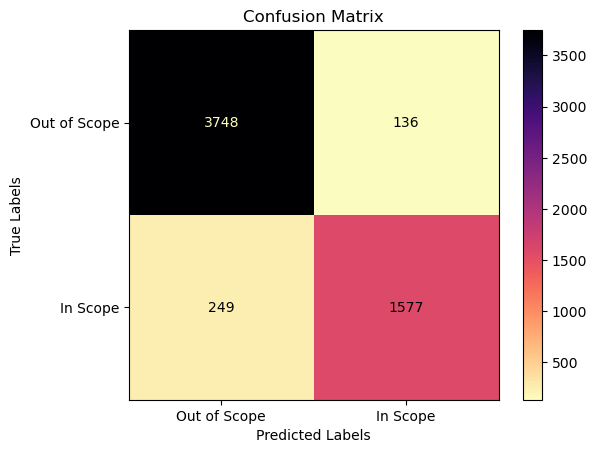

In [72]:
evaluate_file("prediction.tsv")

## Saving and loading the model

To load the model and tokenizer, and to be able to run the trainer and classify standalone sentences, please also run the 'compute_metrics' function.

In [75]:
# model.save_pretrained("BERTModel")

In [76]:
# tokenizer.save_pretrained("Tokenizer")

In [77]:
# this assumes that the model and tokenizer folders are in the same directory as this notebook
pokemon_model = AutoModelForTokenClassification.from_pretrained("BERTModel")
pokemon_tokenizer = AutoTokenizer.from_pretrained("Tokenizer")

In [78]:
# with open("trainer.pkl", "wb") as file:
#     pickle.dump(trainer, file)

In [79]:
def compute_metrics(p):
    """
    Takes as input the predictions and gold labels and calculates evaluation metrics 
    (precision, recall, F1 score, and accuracy) for classification. Special tokens 
    (with label -100) are ignored.

    Parameters:
    p (tuple): A tuple containing:
    - 'predictions': model predictions for each token
    - 'labels': gold labels for each token, with special tokens labeled as -100

    Returns:
    A dictionary with: precision, recall, f-score, and accuracy
    """
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)    # normalizes output in 0 and 1

    # removing ignored index (special tokens)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [80]:
# ATTENTION: for this to work, the function "compute_metrics" needs to be defined
with open("trainer.pkl", "rb") as model_file:
    pokemon_trainer = pickle.load(model_file)

## Classifying a single sentence

To classify a single sentence, we take as input a list of tokens and a list of 0 and 1, with 1 being the negation cue(s). To pass this sentence to BERT, we created a `mega_function` that follows all of the steps above, but without including labels.

In [83]:
def mega_function(sentence_data, pokemon_tokenizer):
    """
    Takes a dataframe that contains two columns: 'word' and 'cue'. It executes all the preprocessing steps for BERT,
    i.e. creating the dictionary which contains the cue values and original cues, the special tokens, the input_ids, attention_mask, 
    word_ids, tokenized_tokens, then it only keeps input_ids and attention_mask and creates the dataset that is used with BERT.

    Parameters:
    sentence_data (dataframe): dataframe created by a single sentence containing the columns 'word' and 'cue'
    pokemon_tokenizer: custom tokenizer with added special negation tokens

    Returns:
    tokenized_data (dictionary): contains all the necessary information to revert the sentence back into its original form
                                 after the subtokenization
    final_dataset (dataset): dataset created using the datasets library, readable by BERT
    """
    
    x = [
            {
                'id': '1',
                'tokens': sentence_data['word'].tolist(),
                'cues': [0 if val == '_' else 1 for val in sentence_data['cue']],
                'og_cues': sentence_data['cue'].tolist()
            }
        ]
    
    y = []
    for sentence in x:
        
        # extracting relevant lists
        tokens = sentence['tokens']
        cues = sentence['cues']
        og_cues = sentence['og_cues']
    
        # counting number of cues (1)
        cue_count = cues.count(1)
    
        # processing tokens based on cues
        processed_tokens = []
        processed_cues = []
        processed_og_cues = []
        for idx, (token, cue) in enumerate(zip(tokens, cues)):
            if cue == 1:
                processed_cues.append(cues[idx])
                processed_og_cues.append(og_cues[idx])
                # Multiple cues: mark as [MULTI]
                if cue_count > 1:
                    processed_tokens.append("[MULTI]")
                # Single cue: mark based on position
                elif og_cues[idx] == token:
                    processed_tokens.append("[NEG]")  
                else:
                    if token.startswith(og_cues[idx]):
                        processed_tokens.append("[PRE]")
                    else:
                        processed_tokens.append("[POST]")
            processed_tokens.append(token)
            processed_cues.append(cues[idx])
            processed_og_cues.append(og_cues[idx])
    
        y.append({
            'tokens':processed_tokens,
            'cues': processed_cues,
            'og_cues': processed_og_cues
        })

    tokenized_data=[]
    for sent in y:
        single_sent={}
        tokenized_input = pokemon_tokenizer(sent["tokens"], is_split_into_words=True)
        tokens = pokemon_tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
        word_ids = tokenized_input.word_ids()
        
        single_sent["input_ids"] = tokenized_input["input_ids"]
        single_sent["attention_mask"] = tokenized_input["attention_mask"]
        single_sent['word_ids'] = word_ids
        single_sent['tokenized_tokens'] = tokens
        tokenized_data.append(single_sent)

    
    processed_data = []
    for example in tokenized_data:
        processed_data.append({
            "input_ids": tokenized_data[0]["input_ids"],
            "attention_mask": tokenized_data[0]["attention_mask"],
        })

        
    final_dataset = Dataset.from_dict({
        'input_ids': [example['input_ids'] for example in processed_data],
        'attention_mask': [example['attention_mask'] for example in processed_data]
    })

    return tokenized_data, final_dataset

In [84]:
def transform_to_test_sentence(sent, target, pokemon_trainer, pokemon_model, pokemon_tokenizer):
    """
    Takes as input a list of strings (tokens) and a list of targets (strings of 0 and 1) and turns them into a dataframe
    with word and cue columns (1 shows the cue). It replaces 0 with '_' and 1 with the cue itself, so that it looks like 
    our input files. Then, this dataframe is used in the mega_function, which executes all the necessary preprocessing steps
    to create the final dataset suitable for BERT. Finally, it predicts, then the special tokens are removed, the majority
    vote of the subtokens is kept, and the final list of predictions is created.

    Parameters:
    sent (list of strings): tokens that make up a sentence. 
    target (list of strings): list which contains as many '0' and '1' as the tokens of 'sent'. '1' represents the negation cue(s).
    pokemon_trainer: trainer that uses the model and tokenizer to classify tokens
    pokemon_model: saved BERT model
    pokemon_tokenizer: custom tokenizer with added special negation tokens

    Returns:
    A list of dictionaries.
    """
    if len(sent) != len(target):
        raise ValueError(
            "The length of the sentence and the array to mark cue must be the same.")

    # creates list of dicts for word and cue
    test_sentence = []
    for token, label in zip(sent, target):
        test_sentence.append(
            {"word": token, "cue": token if label == "1" else '_'})

    # converts list of dicts to dataframe
    sentence_data = pd.DataFrame(test_sentence)
    tokenized_data, final = mega_function(sentence_data, pokemon_tokenizer)

    # print(tokenized_data)
    predictions, _, _ = pokemon_trainer.predict(final)
    predictions = np.argmax(predictions, axis=2)
    
    for idx, i in enumerate(tokenized_data):
        length = len(i['word_ids'])
        i['predictions'] = predictions[idx][:length]

    processed_predictions = []
    for data in tokenized_data:
        word_ids = data['word_ids']
        predictions = data['predictions']
        
        # filtering out elements where labels are -100
        word_ids = [b for a, b in zip(data['tokenized_tokens'], word_ids) if a not in ['[CLS]','[SEP]','[PAD]','[NEG]','[MULTI]','[PRE]','[POST]','[UNK]','[MASK]']]
        predictions = [b for a, b in zip(data['tokenized_tokens'], predictions) if a not in ['[CLS]','[SEP]','[PAD]','[NEG]','[MULTI]','[PRE]','[POST]','[UNK]','[MASK]']]

        # initializing variables to track the current group
        current_word_id = None
        current_predictions = []
        
        for idx, word_id in enumerate(word_ids):
            if word_id != current_word_id:
                # calculating majority vote for the previous group at the start of a new word id
                if current_predictions:
                    processed_predictions.append(Counter(current_predictions).most_common(1)[0][0])
                
                # reset for the new word_id
                current_word_id = word_id
                current_predictions = [predictions[idx]]
            else:
                # add to the current group
                current_predictions.append(predictions[idx])
        
        # handling the last group
        if current_predictions:
            processed_predictions.append(Counter(current_predictions).most_common(1)[0][0])

    return processed_predictions
    

sent = ["She", "does", "n't", "know", "what", "to", "do", "."]
sent_target = ["0", "0", "1", "0", "0", "0", "0", "0"]

# Example usage with model and tokenizer
scope = transform_to_test_sentence(sent, sent_target, pokemon_trainer, pokemon_model, pokemon_tokenizer)
print(scope)

str_scope = ''
for idx, i in enumerate(sent):
    if scope[idx] == 1:
        str_scope += " "+i

print(str_scope)

[1, 1, 0, 1, 1, 1, 1, 0]
 She does know what to do


## Theoretical section

**BERT in negation scope detection and its unique input**

BERT uses the transformer architecture to capture bidirectional context, which allows it to grasp the meaning of a negation cue in relation to all other words in a sentence. BERT can be fine-tuned to support the recognition of how negation cues impact surrounding tokens, which is what makes it highly suitable for this task. Its subword tokenization ensures that all words influenced by negation will be handled effectively by separating them into subtokens that do not necessarily match the input tokens, i.e. the existing words in the dataset that have already been tokenized. After subword tokenization, the tokens that appear can look much different than the input tokens, as shown in the printed examples in the `Preprocessing` section. 

BERT also provides us with the option to add special tokens in its vocabulary, i.e. the negation cue types [NEG], [MULTI], [PRE], and [POST]. These special tokens are responsible for directing its attention to the important parts of the sentence, that is the negation cues. The special negation tokens are added before each negation cue occurence, so that they signify the position of the cue. This augmentation helps BERT to better contextualize the negation cues and their surrounding tokens. 

**Input**

BERT requires specific input to train and classify, therefore a number of preprocessing steps have been added. The print statements in the `Preprocessing` section of the assignment show an example of how each sentence is transformed after going through each preprocessing step. First, each sentence is converted into a list of dictionaries which contain the following keys: id, tokens, labels, cues, og_cues. Special tokens are added to each dictionary ([MULTI], [NEG], [PRE], [POST]) to mark the negation cue with the augmentation technique used in "NegBERT: A Transfer Learning Approach for Negation Detection and Scope Resolution". We add the appropriate special token before each negation cue, as, for example, [MULTI] is added before multi-word negations, [NEG] is added before simple negations, [PRE] is added before prefix negations, and [POST] is added before suffix negations. As special tokens are added, the rest of the dictionary keys are updated with the appropriate padding. Then, the input is given to the tokenizer, which splits the words in subtokens. The input now contains contain input_ids, attention_mask, word_ids, and tokenized_tokens, and is passed to the final preprocessing step, which utilises the Datasets library. This step ensures that our input is in a form recognizable by BERT. 



**Output**

After the predictions have been made, we add them to our dictionary along with the gold labels to be able to create the classification report and confusion matrix. We calculate the number of subtokens for each sentence by counting the word ids, as the remaining predictions and labels are padding. Then, we use those word mappings to return the subtokens in their original form and ensure that the majority of predictions is kept for each token. If there is a tie, then the first token's prediction is chosen. Finally, we flatten the list of lists (predictions) to one list and write the results in a .tsv file. 

Note that all preprocessing and postprocessing steps have printed examples throughout the notebook. 

**Evaluation**

Precision, recall, and F1-score are used for the evaluation of the scope negation detection classifier. Using seed 127, results were quite promising. The macro-average F1-score is 0.916, which shows that the classifier is highly successful in identifying negation scope. Out-of-scope tokens were classified with a higher success rate, achieving an F1-score of 0.948. This can be attributed to the higher prevalence of out-of-scope tokens in both the training and test data. In contrast, in-scope tokens achieved an F1-score of 0.884, with precision slightly exceeding recall (0.910 and 0.859, respectively). Overall, the classifier showed strong performance in the negation scope detection task.

Other tested seeds include seed 99, which presented with the lowest F1-score among the four tested seeds. This, however, does not mean that the results were much different. The macro-average F1-score was 0.913, and the F1-score of out-of-scope and in-scope tokens were 0.946 and 0.881 respectively, scores that are very similar to the scores obtained with seed 127. Seed 71 resulted in the same macro-average F1-score as seed 127 but had the lowest macro-average recall (0.907). Despite this, the overall performance remained consistent. Lastly, the seed 4294967294 showed the highest F1-score out of all fine-tuned models (0.917), yet the difference was insignificant. A slight gap between in-scope precision and recall was observed (0.915 and 0.858 respectively), similarly to the first classifier. 

The "*SEM2012 Shared Task: Resolving the Scope and Focus of Negation" results show that the best performing system achieved an F1-score of 85.26% (closed track) and 82.2% (open track) for scope tokens, both outperformed by our fine-tuned BERT model. However, the shared task first included negation cue detection and then proceeded to scope detection, which is what could explain the relatively lower scores. 

In conclusion, BERT showed consistent performance across all four seeds, with macro-average F1-scores surpassing those of the CRF classifier and achieving results comparable to those of NegBERT. While minor variations were observed in precision and recall, especially for in-scope tokens, the overall findings indicate that BERT can achieve very high results in the negation scope detection task. 


Please note that the results presented were the initial outcomes obtained when running our seeds. Since then, the notebook has been rerun for aesthetic adjustments and to print all required sections. As a result, the printed results differ slightly from those recorded in all four assignments of Group 4.

## References

Khandelwal, A., & Sawant, S. (2020). NegBERT: A transfer learning approach for negation detection and scope resolution. Proceedings of the 12th Conference on Language Resources and Evaluation (LREC 2020), 5739–5748. European Language Resources Association (ELRA).\
https://creativecommons.org/licenses/by-nc/4.0/

Morante, R., & Blanco, E. (2012). *SEM 2012 Shared Task: Resolving the scope and focus of negation. In *SEM 2012: The First Joint Conference on Lexical and Computational Semantics – Volume 1: Proceedings of the main conference and the shared task, and Volume 2: Proceedings of the Sixth International Workshop on Semantic Evaluation (SemEval 2012) (pp. 265–274). Association for Computational Linguistics.\
https://aclanthology.org/S12-1035/